# SBI for ClonalOrigin sequential model and `SimBac` simulation

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
from sbi.diagnostics import run_sbc, check_sbc
from sbi.analysis.plot import sbc_rank_plot
import sys
sys.path.append('../pysimARG')
from G4_test import G4_test
from LD_r import LD_r

torch_device = "cpu"

## Load simulation data

In [2]:
genome_simbac = np.loadtxt("../data/SimBac/genomes_bool.csv", delimiter=",", dtype=bool)

In [3]:
genome_simbac.shape

(15, 1000000)

In [12]:
x_o_500 = np.full(6, np.nan)
x_o_2000 = np.full(6, np.nan)
x_o_6000 = np.full(6, np.nan)

x_o_500[5] = 500
x_o_2000[5] = 2000
x_o_6000[5] = 6000

x_o_500, x_o_2000, x_o_6000

(array([ nan,  nan,  nan,  nan,  nan, 500.]),
 array([  nan,   nan,   nan,   nan,   nan, 2000.]),
 array([  nan,   nan,   nan,   nan,   nan, 6000.]))

In [9]:
i = np.random.randint(0, genome_simbac.shape[1] - 500)
s_vec = np.full(4, np.nan)
mat = genome_simbac[:, i:i+500]
L = 500

has_true = mat.any(axis=0)
has_false = ~mat.all(axis=0)
idx_seg = np.where(has_true & has_false)[0]

ld_near, ld_far, g4_near, g4_far = 0, 0, 0, 0
if idx_seg.size >= 2:
    for i in range(idx_seg.size - 1):
        for j in range(i + 1, idx_seg.size):
            dist_ij = idx_seg[j] - idx_seg[i]
            idx_pair = [idx_seg[i], idx_seg[j]]
            if dist_ij < L/2:
                ld_near += LD_r(mat[:, idx_pair])
                g4_near += G4_test(mat[:, idx_pair])
            else:
                ld_far += LD_r(mat[:, idx_pair])
                g4_far += G4_test(mat[:, idx_pair])
    
    s_far = (int(L/2) + 1) * (int(L/2)) / 2
    s_near = L * (L - 1) / 2 - s_far
    s_vec[0] = ld_near / s_near
    s_vec[1] = ld_far / s_far
    s_vec[2] = g4_near / s_near
    s_vec[3] = g4_far / s_far
else:
    s_vec[:4] = 0

i, s_vec

(63, array([0.00307725, 0.00119518, 0.00119946, 0.00305976]))

In [13]:
x_o_500[:4] = s_vec
count_S = idx_seg.size
x_o_500[4] = count_S / L
x_o_500

array([3.07725197e-03, 1.19518428e-03, 1.19946452e-03, 3.05976096e-03,
       1.30000000e-01, 5.00000000e+02])

In [14]:
i = np.random.randint(0, genome_simbac.shape[1] - 2000)
s_vec = np.full(4, np.nan)
mat = genome_simbac[:, i:i+2000]
L = 2000

has_true = mat.any(axis=0)
has_false = ~mat.all(axis=0)
idx_seg = np.where(has_true & has_false)[0]

ld_near, ld_far, g4_near, g4_far = 0, 0, 0, 0
if idx_seg.size >= 2:
    for i in range(idx_seg.size - 1):
        for j in range(i + 1, idx_seg.size):
            dist_ij = idx_seg[j] - idx_seg[i]
            idx_pair = [idx_seg[i], idx_seg[j]]
            if dist_ij < L/2:
                ld_near += LD_r(mat[:, idx_pair])
                g4_near += G4_test(mat[:, idx_pair])
            else:
                ld_far += LD_r(mat[:, idx_pair])
                g4_far += G4_test(mat[:, idx_pair])
    
    s_far = (int(L/2) + 1) * (int(L/2)) / 2
    s_near = L * (L - 1) / 2 - s_far
    s_vec[0] = ld_near / s_near
    s_vec[1] = ld_far / s_far
    s_vec[2] = g4_near / s_near
    s_vec[3] = g4_far / s_far
else:
    s_vec[:4] = 0

i, s_vec

(254, array([0.00259854, 0.00206854, 0.00214548, 0.00356244]))

In [15]:
x_o_2000[:4] = s_vec
count_S = idx_seg.size
x_o_2000[4] = count_S / L
x_o_2000

array([2.59853740e-03, 2.06854165e-03, 2.14547881e-03, 3.56243756e-03,
       1.28000000e-01, 2.00000000e+03])

In [16]:
i = np.random.randint(0, genome_simbac.shape[1] - 6000)
s_vec = np.full(4, np.nan)
mat = genome_simbac[:, i:i+6000]
L = 6000

has_true = mat.any(axis=0)
has_false = ~mat.all(axis=0)
idx_seg = np.where(has_true & has_false)[0]

ld_near, ld_far, g4_near, g4_far = 0, 0, 0, 0
if idx_seg.size >= 2:
    for i in range(idx_seg.size - 1):
        for j in range(i + 1, idx_seg.size):
            dist_ij = idx_seg[j] - idx_seg[i]
            idx_pair = [idx_seg[i], idx_seg[j]]
            if dist_ij < L/2:
                ld_near += LD_r(mat[:, idx_pair])
                g4_near += G4_test(mat[:, idx_pair])
            else:
                ld_far += LD_r(mat[:, idx_pair])
                g4_far += G4_test(mat[:, idx_pair])
    
    s_far = (int(L/2) + 1) * (int(L/2)) / 2
    s_near = L * (L - 1) / 2 - s_far
    s_vec[0] = ld_near / s_near
    s_vec[1] = ld_far / s_far
    s_vec[2] = g4_near / s_near
    s_vec[3] = g4_far / s_far
else:
    s_vec[:4] = 0

i, s_vec

(928, array([0.00347136, 0.00304633, 0.00534363, 0.00545263]))

In [17]:
x_o_6000[:4] = s_vec
count_S = idx_seg.size
x_o_6000[4] = count_S / L
x_o_6000

array([3.47135924e-03, 3.04632644e-03, 5.34363306e-03, 5.45262690e-03,
       1.55000000e-01, 6.00000000e+03])

In [18]:
theta = np.loadtxt('../data/theta.csv', delimiter=",")
x = np.loadtxt('../data/x.csv', delimiter=",")

x = x[:, [0, 1, 2, 3, 5, 6]]
print(theta.shape, x.shape)
x[:10, :]

(5000, 4) (5000, 6)


array([[1.11265499e-02, 1.14205470e-02, 9.95204411e-03, 1.05786445e-02,
        2.81263381e-01, 9.34000000e+03],
       [9.43834457e-05, 8.23004157e-05, 1.70289655e-04, 2.25289463e-04,
        3.01039964e-02, 1.82700000e+03],
       [1.76203437e-02, 1.69849414e-02, 3.05095520e-02, 3.03991847e-02,
        3.86508673e-01, 2.19400000e+03],
       [1.04513429e-02, 1.08466577e-02, 1.08426195e-02, 1.06987879e-02,
        2.56880730e-01, 3.27000000e+02],
       [4.26535234e-02, 4.31486107e-02, 1.39270455e-01, 1.47897527e-01,
        7.15102136e-01, 8.22400000e+03],
       [3.48350841e-05, 2.77148865e-05, 2.80820714e-05, 3.34033502e-05,
        1.55895688e-02, 3.52800000e+03],
       [8.38595349e-03, 8.35136790e-03, 1.92584898e-02, 2.04953831e-02,
        2.95516431e-01, 5.50900000e+03],
       [2.04484724e-02, 1.73530765e-02, 5.22633381e-02, 4.21962254e-02,
        4.48257089e-01, 9.18000000e+03],
       [3.21496068e-03, 2.91783712e-03, 6.14848407e-03, 6.80776034e-03,
        1.96764708e-01, 

In [19]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()
theta

tensor([[1.3740e-01, 2.0075e+01, 1.3690e-01, 9.3400e+03],
        [6.4356e-02, 2.1824e+02, 5.8822e-03, 1.8270e+03],
        [7.4060e-02, 1.1324e+02, 1.3170e-01, 2.1940e+03],
        ...,
        [5.9294e-02, 1.9140e+02, 1.7278e-01, 3.9520e+03],
        [8.5187e-02, 2.6280e+02, 7.1654e-02, 8.0960e+03],
        [4.8094e-03, 4.9657e+02, 1.4620e-01, 2.5760e+03]])

In [20]:
x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()
x

tensor([[1.1127e-02, 1.1421e-02, 9.9520e-03, 1.0579e-02, 2.8126e-01, 9.3400e+03],
        [9.4383e-05, 8.2300e-05, 1.7029e-04, 2.2529e-04, 3.0104e-02, 1.8270e+03],
        [1.7620e-02, 1.6985e-02, 3.0510e-02, 3.0399e-02, 3.8651e-01, 2.1940e+03],
        ...,
        [2.5568e-02, 2.2119e-02, 5.6426e-02, 5.7131e-02, 4.7293e-01, 3.9520e+03],
        [7.1386e-03, 6.7166e-03, 1.6868e-02, 1.4219e-02, 2.7446e-01, 8.0960e+03],
        [1.6939e-02, 9.7364e-03, 9.0992e-03, 1.0935e-02, 2.9425e-01, 2.5760e+03]])

In [21]:
theta.shape, x.shape

(torch.Size([5000, 4]), torch.Size([5000, 6]))

In [23]:
x_o_500_numpy = x_o_500.copy()
x_o_2000_numpy = x_o_2000.copy()
x_o_6000_numpy = x_o_6000.copy()

In [24]:
x_o_500 = torch.tensor(x_o_500, device=torch_device)
x_o_500 = x_o_500.to(torch.float32)

x_o_2000 = torch.tensor(x_o_2000, device=torch_device)
x_o_2000 = x_o_2000.to(torch.float32)

x_o_6000 = torch.tensor(x_o_6000, device=torch_device)
x_o_6000 = x_o_6000.to(torch.float32)

In [25]:
x_o_2000.dtype, x_o_500.dtype, x_o_6000.dtype, theta.dtype, x.dtype

(torch.float32, torch.float32, torch.float32, torch.float32, torch.float32)

## Fit NPE

In [26]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference = NPE_C(density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [27]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 133 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-05-01T11_26_11.809265' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


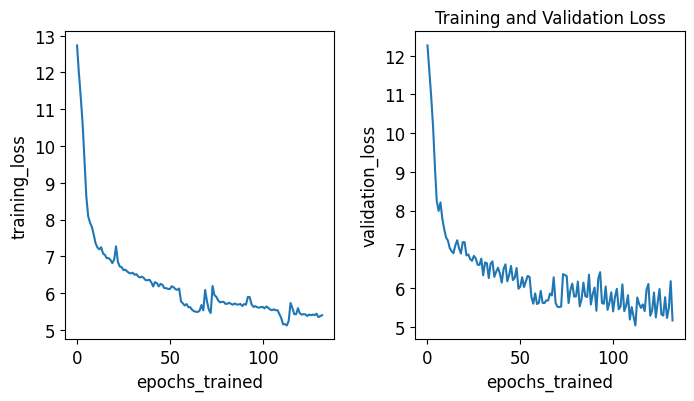

In [28]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

## Posterior distributions for different sequence length

In [30]:
theta_trained_2000 = posterior.set_default_x(x_o_2000).sample((num_posterior_samples,), x=x_o_2000)
theta_trained_2000_numpy = theta_trained_2000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 35503.43it/s]


In [31]:
theta_trained_500 = posterior.set_default_x(x_o_500).sample((num_posterior_samples,), x=x_o_500)
theta_trained_500_numpy = theta_trained_500.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 54422.71it/s]


In [32]:
theta_trained_6000 = posterior.set_default_x(x_o_6000).sample((num_posterior_samples,), x=x_o_6000)
theta_trained_6000_numpy = theta_trained_6000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 28745.83it/s]


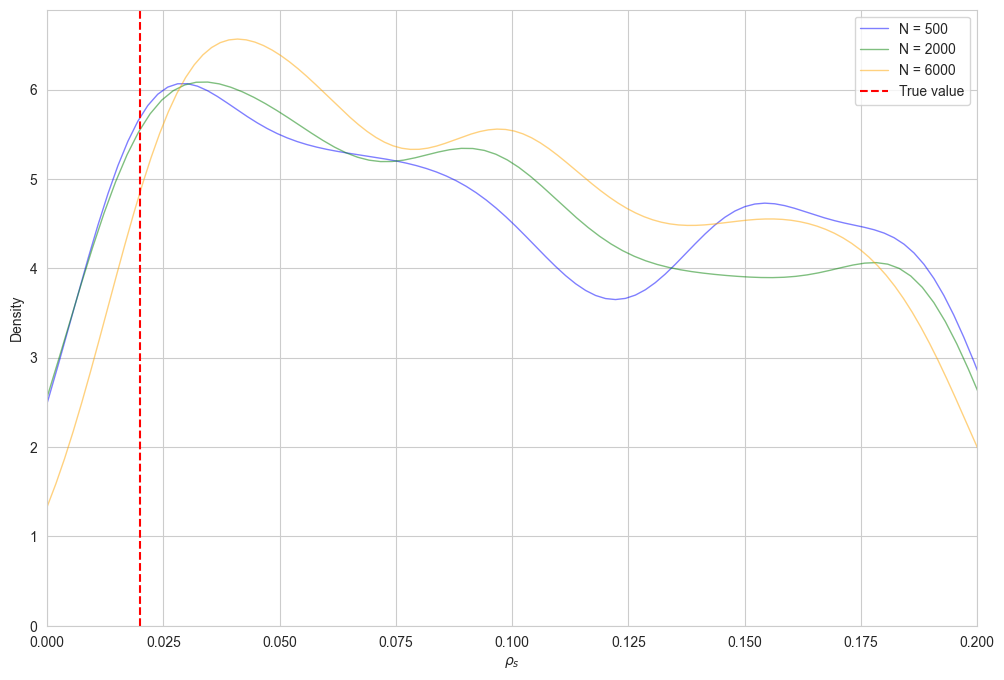

In [33]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 0], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 0], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 0], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

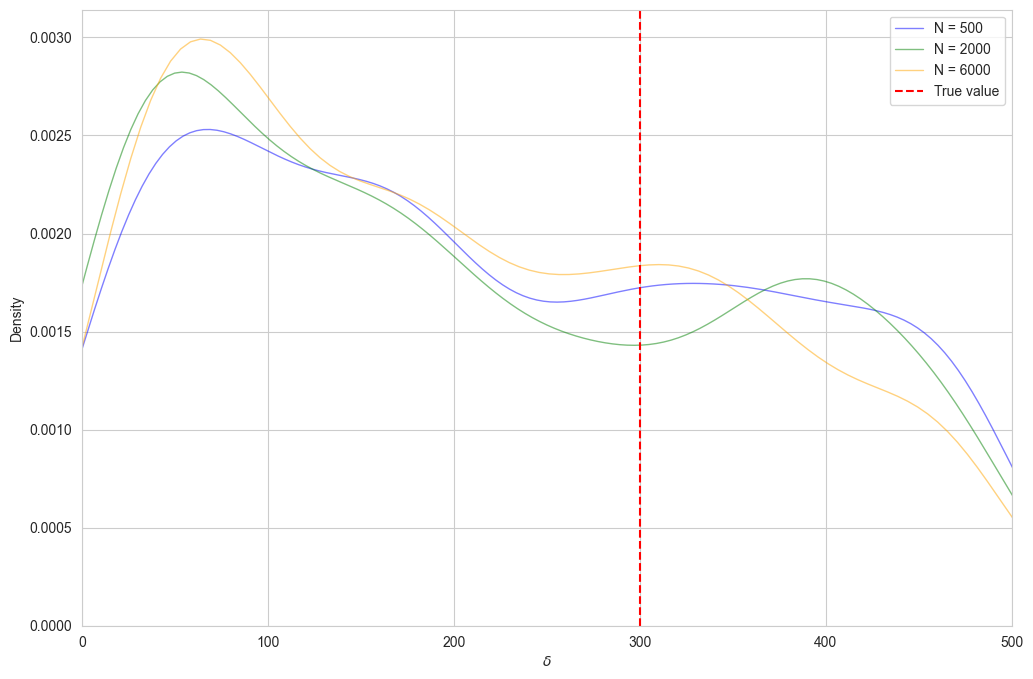

In [34]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 1], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 1], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 1], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=300, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\delta$')
plt.xlim(0.0, 500.0)
plt.legend()
plt.show()

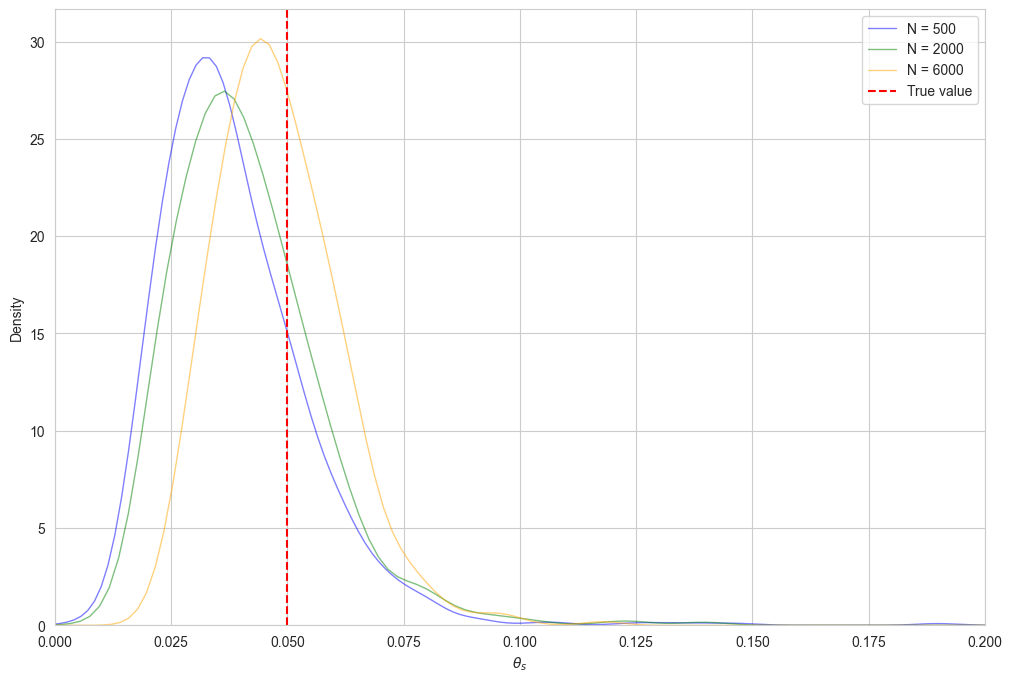

In [35]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 2], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 2], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 2], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.05, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\theta_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

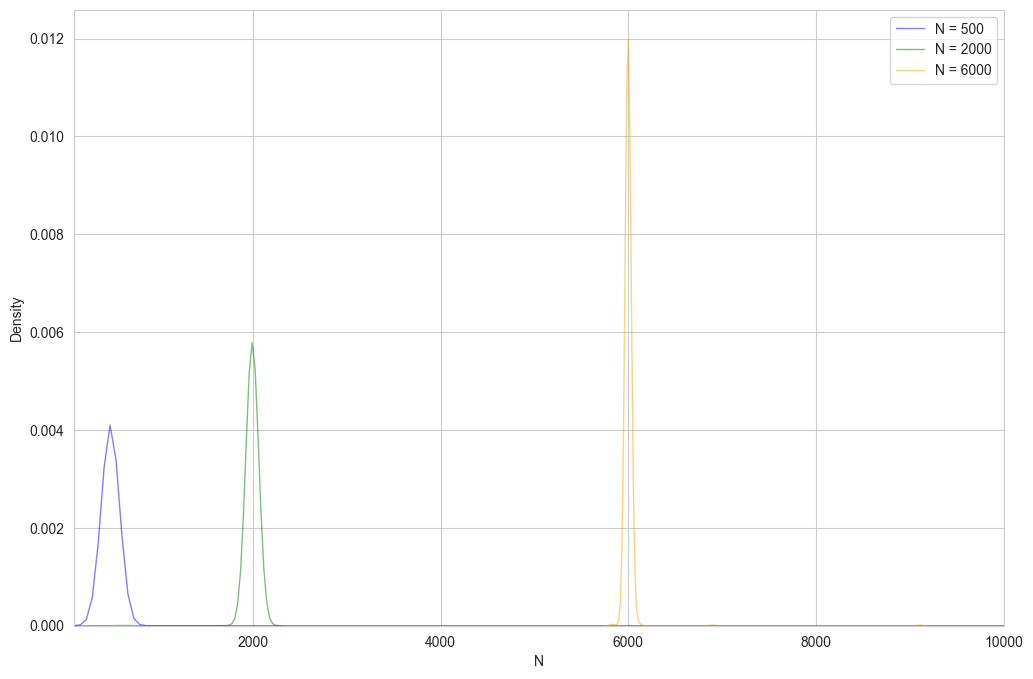

In [36]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 3], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 3], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 3], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

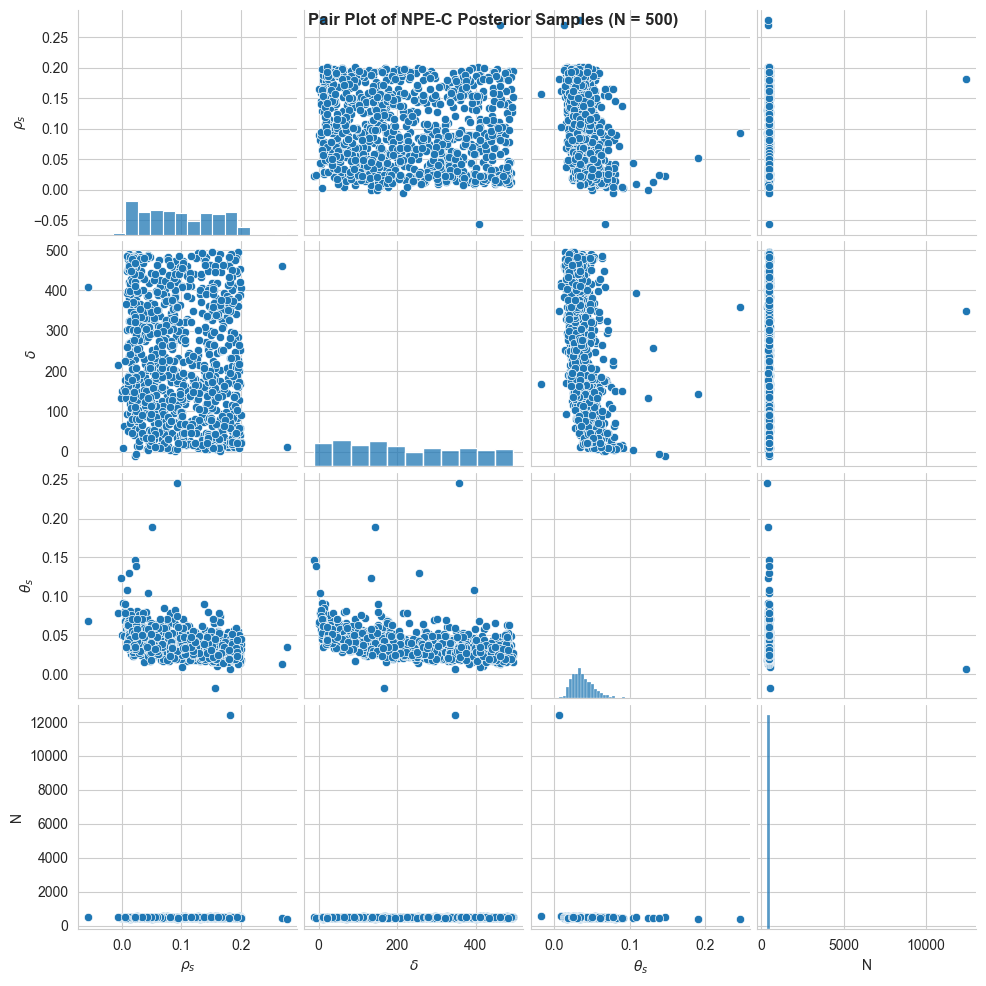

In [37]:
df_500 = pd.DataFrame(theta_trained_500_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

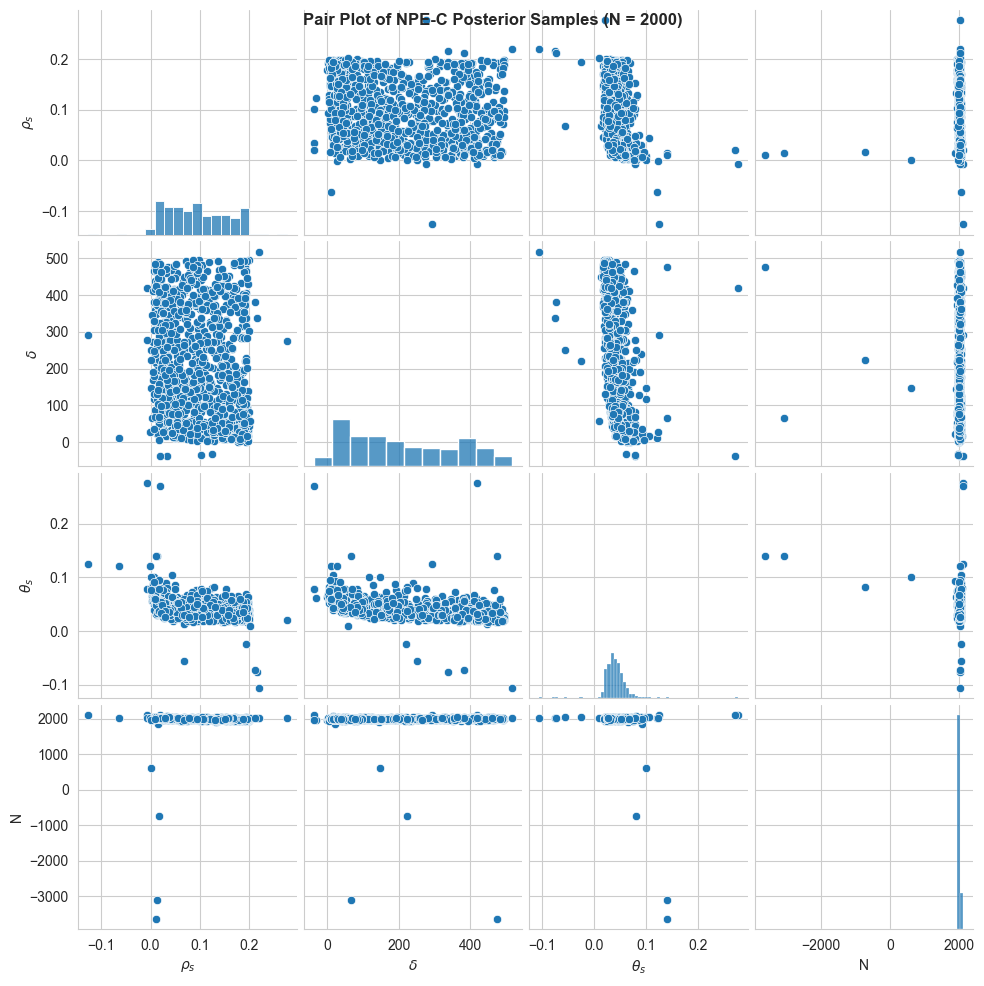

In [38]:
df_2000 = pd.DataFrame(theta_trained_2000_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

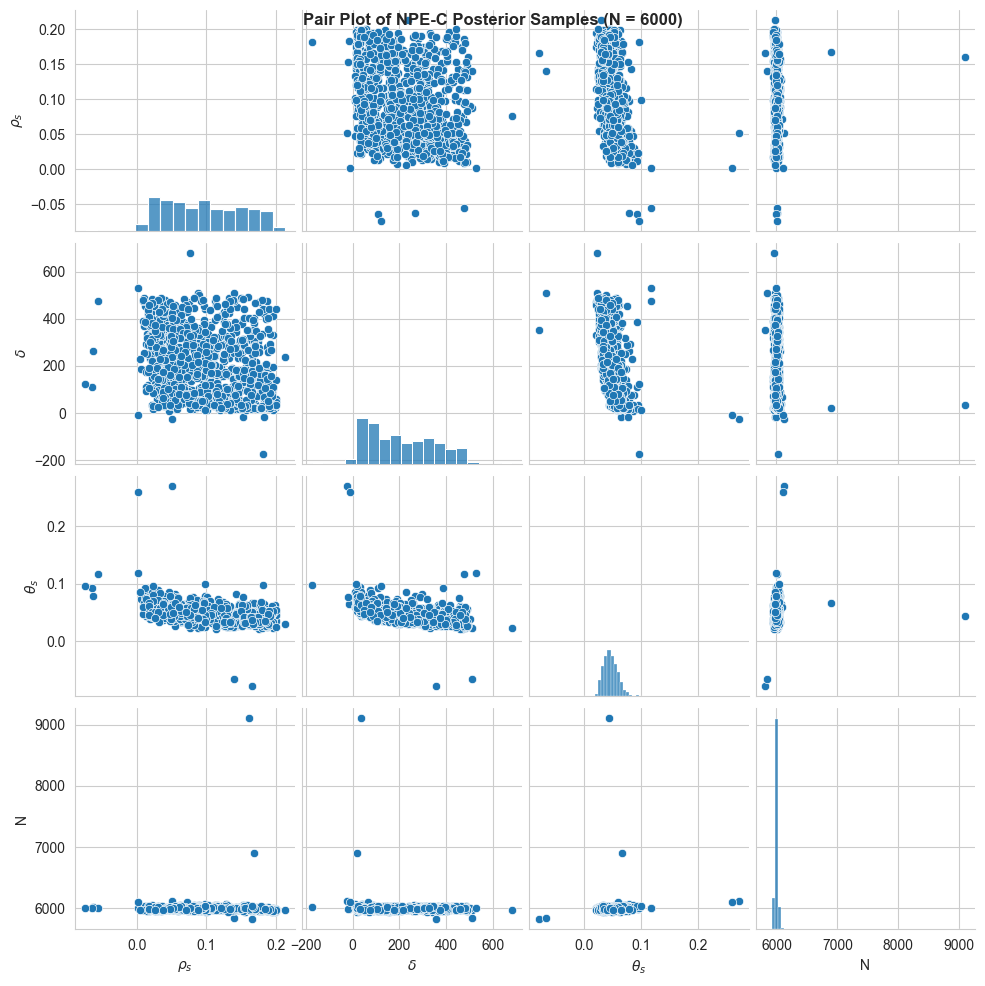

In [39]:
df_6000 = pd.DataFrame(theta_trained_6000_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

## SBC

In [40]:
theta_sbc = np.loadtxt('../data/theta_sbc.csv', delimiter=",")
theta_sbc = torch.tensor(theta_sbc, device=torch_device)
theta_sbc = theta_sbc.to(torch.float32)
theta_sbc_numpy = theta_sbc.cpu().numpy()
theta_sbc

tensor([[5.1383e-03, 1.4845e+02, 1.4089e-01, 4.7100e+02],
        [1.2469e-02, 9.9647e+01, 1.8214e-01, 3.9640e+03],
        [4.4089e-02, 2.0442e+02, 6.6897e-02, 9.3510e+03],
        ...,
        [1.6944e-02, 2.8099e+01, 1.2512e-01, 9.7710e+03],
        [1.6703e-01, 1.6843e+02, 1.9089e-01, 8.3000e+03],
        [1.5217e-01, 4.9434e+02, 1.1356e-02, 5.7700e+02]])

In [41]:
x_sbc = np.loadtxt('../data/x_sbc.csv', delimiter=",")
x_sbc = x_sbc[:, [0, 1, 2, 3, 5, 6]]
x_sbc = torch.tensor(x_sbc, device=torch_device)
x_sbc = x_sbc.to(torch.float32)
x_sbc_numpy = x_sbc.cpu().numpy()
x_sbc

tensor([[1.1051e-02, 7.7154e-03, 2.7605e-03, 3.0292e-03, 2.5690e-01, 4.7100e+02],
        [1.5444e-02, 1.4497e-02, 6.1859e-03, 6.2565e-03, 2.9692e-01, 3.9640e+03],
        [4.3055e-03, 4.6157e-03, 6.6693e-03, 7.0312e-03, 2.0361e-01, 9.3510e+03],
        ...,
        [6.6039e-03, 6.6610e-03, 1.2362e-03, 1.2946e-03, 2.0244e-01, 9.7710e+03],
        [2.8857e-02, 2.9172e-02, 8.5235e-02, 8.5103e-02, 5.7675e-01, 8.3000e+03],
        [1.1264e-03, 5.0690e-04, 3.6930e-04, 4.0850e-04, 9.3588e-02, 5.7700e+02]])

In [42]:
theta_sbc.shape, x_sbc.shape

(torch.Size([500, 4]), torch.Size([500, 6]))

In [43]:
theta_sbc.dtype, x_sbc.dtype

(torch.float32, torch.float32)

In [45]:
sbc_results = []
np.random.seed(100)
torch.manual_seed(100)
ranks, dap_samples = run_sbc(
    theta_sbc, 
    x_sbc, 
    posterior, 
    num_posterior_samples=1000,
    use_batched_sampling=False
)

stats = check_sbc(
    ranks, 
    theta_sbc, 
    dap_samples, 
    num_posterior_samples=1000
)

sbc_results.append({
    "ranks": ranks, 
    "stats": stats
})

Calculating ranks for 500 SBC samples: 100%|██████████| 500/500 [00:00<00:00, 12331.26it/s]


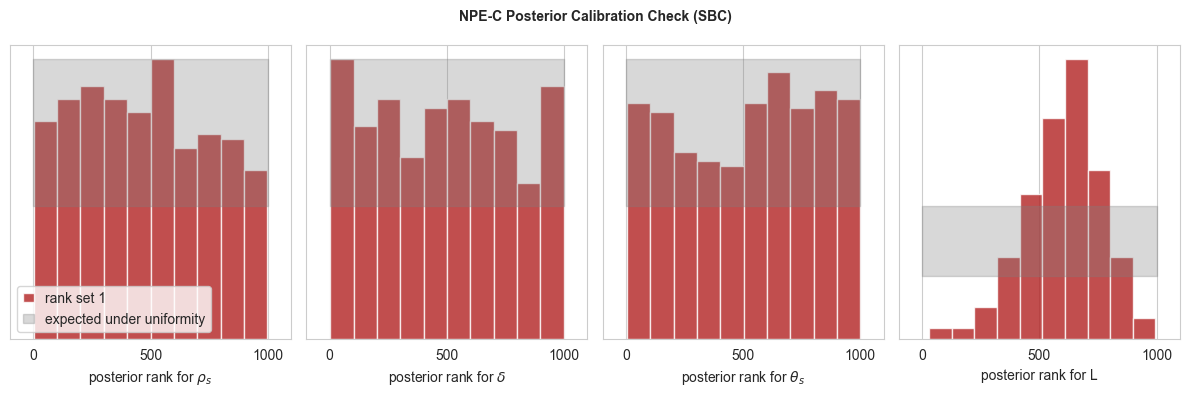

In [47]:
fig, ax = sbc_rank_plot(
    ranks, 
    num_posterior_samples, 
    plot_type="hist", 
    num_bins=10, 
    figsize=(12, 4),
    parameter_labels=[r"for $\rho_s$", r"for $\delta$", r"for $\theta_s$", r"for L"]
)

fig.suptitle('NPE-C Posterior Calibration Check (SBC)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def plot_sbc_ecdf_diff(ranks, num_posterior_samples, param_names=None):
    """
    Plots the ECDF Difference plot for SBC ranks.
    """
    ranks_np = np.array(ranks)
    num_sims, num_params = ranks_np.shape
    
    plt.figure(figsize=(10, 6))

    x_eval = np.linspace(0, 1, 1000)

    std_err = np.sqrt(x_eval * (1 - x_eval) / num_sims)
    envelope_upper = 1.96 * std_err
    envelope_lower = -1.96 * std_err

    plt.fill_between(x_eval, envelope_lower, envelope_upper, color='grey', alpha=0.3, label='95% Confidence')
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

    for i in range(num_params):
        param_ranks = ranks_np[:, i] / num_posterior_samples

        empirical_cdf = np.searchsorted(np.sort(param_ranks), x_eval, side='right') / num_sims

        diff = empirical_cdf - x_eval
        
        label = param_names[i] if param_names else f'Param {i}'
        plt.plot(x_eval, diff, label=label, linewidth=2)

    plt.title("SBC ECDF Difference Plot")
    plt.xlabel("Fractional Rank")
    plt.ylabel("Difference from Uniform CDF")
    plt.legend()
    plt.show()

C:\Users\u2008181\AppData\Local\Temp\ipykernel_1628\3289911692.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ranks_np = np.array(ranks)


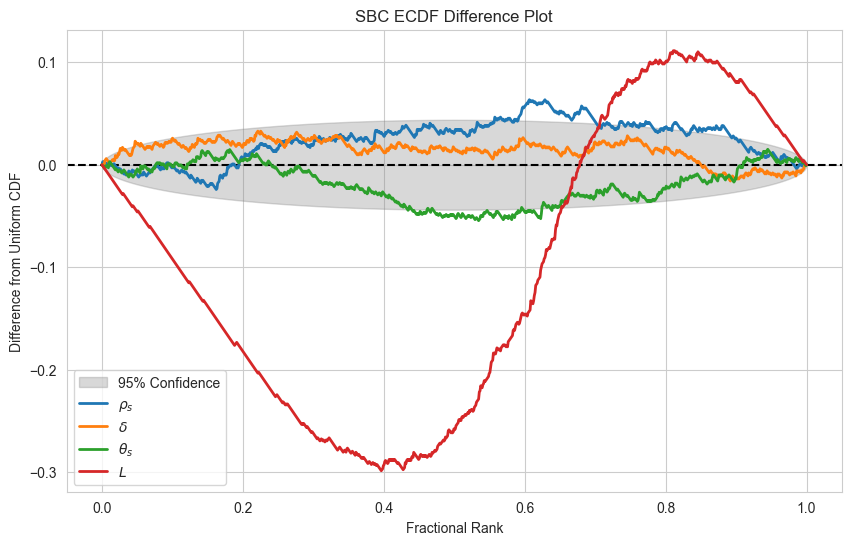

In [49]:
plot_sbc_ecdf_diff(ranks, num_posterior_samples=1000, param_names=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", r"$L$"])